#### CMSE 381 Final Project
### &#9989; Group members: Jack Cienkus, Kathryn Tumavitch
### &#9989; Section_002
#### &#9989; 04/24/2026

---

# Is School Type influential to Exam score? Can we predict School Type based on Exam Score? Is School Type within the top three most influential factors for predicting Exam score?

---

## Background and Motivation

As tuition of private schools is rapidly increasing [1], our goal was to investigate if they really justified their cost. While we acknowledge that private schools often offer other advantages, such as networking opportunities or general prestige, those are difficult to quantify. Thus, we decided to investigate the reletive merits of public vs private schools through the lens of academic performance. This was done through determining if school type can be predicted when given a students exam score, and if school type is within the top three most influential predictors of exam score.

---

## Methodology

The first step was to clean the data. To do this, we created a `pandas` dataframe, and dropped any row that had a missing value. After doing this, we created two subsets of the data - One containing the exam scores per student, and another containing the school type per student. Then, using `train_test_split` from `sklearn`, we created a training set and a test set of the data. The training set contained 80% of the data, and the test set contained 20% of the data. From there, we trained a logistic regression model and a random forest classifier, both by using `sklearn`. We chose these two models specifically, as they use vastly different methods to classify, and by training both, we have a better chance at finding the optimal classifier. After training them both, they were evaluated by using `sklearn`'s `accuracy_score`, `classification_report`, and `ConfusionMatrixDisplay`. After this, two new subsets were made - one containing exam scores per student, and another containing the rest of the data.
From there, they were split into training and test sets, using the same proportions as last time for the split. Once this was complete, a linear regression model was trained twice using both forward selection and backward selection for the features. They were evaluated with $R^2$, RMSE, and a graph depicting number of features vs $R^2$ score. Then, a random forest regresor was trained with the same train-test subsets as before, along with a grid-search cross-validation used for pruning. It was evaluated with $R^2$ and RMSE. Finally, a different random forest regressor was trained using 5-fold cross validation on the data, also using $R^2$ and RMSE for evaluation.

#### Data

The data used in this study is from "Student Academic Performance Dataset", created by a user on Kaggle named "ayeshasiddiqa123." The dataset name explains what kind of data is involved; It's student academic performance data. There's information for 6,607 students, and the features collected for each are as follows: `Hours_Studied`, which tracks the number of hours studied, `Attendance`, which tracks attendance as a percentage, `Parental_Involvement`, which classifies the amount of parental involvement as "Low", "Medium", or "High", `Access_to_Resources`, which classifies the student's access to resources, `Extracurricular_Activities`, which classifies whether or not a student had extracurricular activities as "Yes" or "No", `Sleep_Hours`, which tracks average hours of sleep, `Previous_Scores`, which tracks previous exam scores, `Motivation_Level`, which classifies motivation level as "Low", "Medium", or "High", `Internet_Access`, which classifies whether or not a student had internet access, `Tutoring_Sessions`, which tracks number of tutoring sessions, `Family_Income`, which classifies family income as "Low", "Medium", or "High", `Teacher_Quality`, which classifies teacher quality as "Low", "Medium", or "High", `School_Type`, which classifies type of school as "Public" or "Private", `Peer_Influence`, which classifies peer influence as "Positive", "Neutral", or "Negative", `Physical_Activity`, which tracks the amount of physical activity, `Learning_Disabilities`, which classifies whether or not they have a learning disability as "Yes" or "No", `Parental_Education_Level`, which classifies level of parental education as "High School", "College", or "Postgraduate", `Distance_From_Home`, which classifies distance between school and home as "Near", "Moderate", or "Far", `Gender`, which classifies gender as "Male" or "Female", and `Exam_Score`, which tracks their exam score. All features are used in this study. The cleaning done to this data consists of removing a row of data if there's an instance of a missing value. After doing this, the amount of rows became 6,378.

#### Code

In [1]:
# Import necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, 
    root_mean_squared_error, 
    classification_report, 
    accuracy_score, 
    ConfusionMatrixDisplay
)

# Load data (with pandas)
df = pd.read_csv('StudentPerformanceFactors.csv')

# Drop rows where target is missing
df = df.dropna()

Above, we're importing the packages necessary for the code to function. Next, we created our first classifier, which is the logistic regression model. We also calculated evaluation metrics and created a confusion matrix for the model.

In [2]:
###################################################################################
#
#   Logistic regression model to classify school type based on exam score
#
###################################################################################

# Create data subsets
X_class = pd.DataFrame(df['Exam_Score'])
y_class = df['School_Type']

# Create the logistic regression model object
clf_lr = LogisticRegression(random_state=12, class_weight='balanced', max_iter=1000)

# Split the data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=12)

# Train the model
clf_lr.fit(X_train_class, y_train_class)

# Evaluate
y_pred_lr = clf_lr.predict(X_test_class)
acc_lr = accuracy_score(y_test_class, y_pred_lr)
report_lr = classification_report(y_test_class, y_pred_lr)

Next, we created a random forest classifier using the same split data as before. 

In [3]:
###################################################################################
#
#   Random forest classifier model to predict school type based on exam score
#
###################################################################################

# Create data subsets
clf_rf = RandomForestClassifier(random_state=12, n_estimators=100, class_weight='balanced')

# Train the model
clf_rf.fit(X_train_class, y_train_class)

# Predict and Evaluate
y_pred_rfc = clf_rf.predict(X_test_class)
acc_rfc = accuracy_score(y_test_class, y_pred_rfc)
report_rfc = classification_report(y_test_class, y_pred_rfc)

Now that the classifiers were created and evaluated, the regression models were next. Before coding them, we created new subsets of the data.

In [4]:
### Create new data subsets for regression

X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

# Create one-hot-oncoding for qualitative features
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=12)
X_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,True,False,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,True,False,False,True,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,False,True,False,True,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,True,False,False,True,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,False,True,False,True,...,False,True,True,False,False,False,False,False,True,False


`pd.get_dummies` creates a new dataframe that contains one-hot encodings of each column containing qualitative data. For example, `Parental_Involvement` has three classes, being "High", "Medium", and "Low". `pd.get_dummies` sees this, deletes the original column, and creates two new columns, being `Parental_Involvement_Low` and `Parental_Involvement_Medium`, each filled with boolean values. This allows models to be trained by `sklearn`, as they don't have the capability to train a model with a column containing three or more unique classes.

Now that the models for classifying school type based on exam score were complete, we had to code regression models which predict exam scores based on every other feature. To do this, we created linear regression models that perform forward feature selection and backward feature selection, a random forest regressor with post-train pruning, and an unpruned random forest regressor using 5-fold cross-validation. First up, linear regression with forward feature selection.

In [5]:
###################################################################################
#
#  Function to perform forward feature selection with linear regression
#
###################################################################################

def plot_and_evaluate_forward_selection(X_train, X_test, y_train, y_test):
    print(f"\n{'='*20}\nForward Selection\n{'='*20}")
    
    total_features = X_train.shape[1]
    selected_features = []
    remaining_features = list(X_train.columns)
    cv_r2_scores = []
    
    lin_reg = LinearRegression()
    
    # Select based purely on Cross-Validated R^2
    for i in range(1, total_features + 1):
        best_cv_r2 = -np.inf
        best_feature = None
        
        for feature in remaining_features:
            test_features = selected_features + [feature]
            # CV evaluated ONLY on training data
            score = cross_val_score(lin_reg, X_train[test_features], y_train, cv=5, scoring='r2').mean()
            
            if score > best_cv_r2:
                best_cv_r2 = score
                best_feature = feature
                
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        cv_r2_scores.append(best_cv_r2)
        
    # Find the peak of the CV curve
    max_cv_r2 = max(cv_r2_scores)
    optimal_num = cv_r2_scores.index(max_cv_r2) + 1
    best_feature_names = selected_features[:optimal_num]
    
    print(f"Optimal Number of Features: {optimal_num} (Out of {total_features})")
    print(f"Selected Features: {best_feature_names}")
    
    # Train final model on optimally selected features
    lin_reg.fit(X_train[best_feature_names], y_train)
    y_pred = lin_reg.predict(X_test[best_feature_names])
    
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Out-of-Sample (Test) R-squared: {test_r2:.3f}")
    print(f"Out-of-Sample (Test) RMSE: {test_rmse:.3f}")
    
    # Display Top 3 Features
    # Handle edge case where optimal features are less than 3
    num_to_display = min(3, len(best_feature_names))
    coef_magnitudes = np.abs(lin_reg.coef_)
    top_indices = np.argsort(coef_magnitudes)[-num_to_display:][::-1]
    top_features = [best_feature_names[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by absolute coefficient): {top_features}")
    
    # Feature Selection Curve Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.plot(range(1, total_features + 1), cv_r2_scores, marker='o', linestyle='-')
    ax.set_title(f'Feature Selection Curve')
    ax.set_xlabel('Number of Features Selected')
    ax.set_ylabel('Cross-Validated $R^2$ (Training Only)')
    ax.axvline(x=optimal_num, color='red', linestyle='--', 
                label=f'Optimal: {optimal_num}\n(Max CV $R^2$: {max_cv_r2:.3f})')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

Next, linear regression with backward feature selection.

In [6]:
###################################################################################
#
#  Function to perform backward feature selection with linear regression
#
###################################################################################

def plot_and_evaluate_backward_selection(X_train, X_test, y_train, y_test):
    print(f"\n{'='*20}\nBackward Selection\n{'='*20}")
    
    lin_reg = LinearRegression()
    current_features = list(X_train.columns)
    total_features = len(current_features)
    
    # Tracking variables
    cv_r2_scores = []
    feature_sets_history = []
    
    # Evaluate the baseline model with ALL features
    initial_score = cross_val_score(lin_reg, X_train[current_features], y_train, cv=5, scoring='r2').mean()
    cv_r2_scores.append(initial_score)
    feature_sets_history.append(list(current_features))
    
    # Iteratively drop one feature at a time
    for i in range(total_features - 1, 0, -1):
        best_cv_r2 = -np.inf
        feature_to_drop = None
        
        # Test dropping each remaining feature
        for feature in current_features:
            test_features = [f for f in current_features if f != feature]
            score = cross_val_score(lin_reg, X_train[test_features], y_train, cv=5, scoring='r2').mean()
            
            # Find the feature whose removal results in the highest remaining CV score
            if score > best_cv_r2:
                best_cv_r2 = score
                feature_to_drop = feature
                
        # Drop the worst-performing feature from the current pool
        current_features.remove(feature_to_drop)
        cv_r2_scores.append(best_cv_r2)
        feature_sets_history.append(list(current_features))
        
    # Reverse the histories so the x-axis reads from 1 up to total_features (matching the forward selection plot)
    cv_r2_scores.reverse()
    feature_sets_history.reverse()
    
    # Find the peak of the CV curve
    max_cv_r2 = max(cv_r2_scores)
    optimal_index = cv_r2_scores.index(max_cv_r2)
    optimal_num = optimal_index + 1
    best_feature_names = feature_sets_history[optimal_index]
    
    print(f"Optimal Number of Features: {optimal_num} (Out of {total_features})")
    print(f"Selected Features: {best_feature_names}")
    
    # Train final model on optimally selected features
    lin_reg.fit(X_train[best_feature_names], y_train)
    y_pred = lin_reg.predict(X_test[best_feature_names])
    
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Out-of-Sample (Test) R-squared: {test_r2:.3f}")
    print(f"Out-of-Sample (Test) RMSE: {test_rmse:.3f}")
    
    # Display Top 3 Features
    num_to_display = min(3, len(best_feature_names))
    coef_magnitudes = np.abs(lin_reg.coef_)
    top_indices = np.argsort(coef_magnitudes)[-num_to_display:][::-1]
    top_features = [best_feature_names[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by absolute coefficient): {top_features}")
    
    # Feature Selection Curve Plot
    fig, ax= plt.subplots(figsize=(6, 5))
    
    ax.plot(range(1, total_features + 1), cv_r2_scores, marker='o', linestyle='-', color='darkorange')
    ax.set_title(f'Feature Selection Curve')
    ax.set_xlabel('Number of Features Remaining')
    ax.set_ylabel('Cross-Validated $R^2$ (Training Only)')
    ax.axvline(x=optimal_num, color='red', linestyle='--', 
                label=f'Optimal: {optimal_num}\n(Max CV $R^2$: {max_cv_r2:.3f})')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

Now, onto the random forest regressors. First, the pruned random forest regressor. The technique used to prune is `ccp_alpha` optimization with grid search cross-validation from `sklearn`. 

In [7]:
###################################################################################
#
#  Function for Pruned Random Forest Regressor using Train-Test Split (See [2])
#
###################################################################################

def evaluate_pruned_random_forest(X_train, X_test, y_train, y_test):
    print(f"\n{'='*25}\nRandom Forest Pruning\n{'='*25}")
    
    rf = RandomForestRegressor(random_state=12, n_jobs=-1)
    
    # Grid Search for optimal complexity penalty (ccp_alpha)
    param_grid = {'ccp_alpha': np.linspace(0, 0.05, 10)}
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    
    print("Running Grid Search...")
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    
    print(f"Best ccp_alpha: {grid_search.best_params_['ccp_alpha']:.4f}")
    
    # Evaluate final model on the independent test set
    y_pred = best_rf.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Test Set R-squared: {test_r2:.3f}")
    print(f"Test Set RMSE: {test_rmse:.3f}")
    
    # Display Top 3 Features
    num_to_display = min(3, len(X_train.columns))
    importances = best_rf.feature_importances_
    top_indices = np.argsort(importances)[-num_to_display:][::-1]
    top_features = [X_train.columns[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by RF Importance): {top_features}")

And finally, the unpruned random forest regressor using 5-fold CV.

In [8]:
def evaluate_unpruned_random_forest(X, y):
    print(f"\n{'='*35}\nUnpruned Random Forest 5-Fold CV\n{'='*35}")
    
    # Create the random forest regressor object
    tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)
    
    # Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
    cv_r2_scores = cross_val_score(tree_reg_model, X, y, cv=5, scoring='r2')
    cv_neg_mse_scores = cross_val_score(tree_reg_model, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)
    
    # Print results
    print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
    print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
    print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
    print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

    # Display Top 3 Features
    # We must fit the model once on the full passed-in X, y to extract feature importances
    tree_reg_model.fit(X, y)
    num_to_display = min(3, len(X.columns))
    importances = tree_reg_model.feature_importances_
    top_indices = np.argsort(importances)[-num_to_display:][::-1]
    top_features = [X.columns[i] for i in top_indices]
    print(f"Top {num_to_display} Most Impactful Features (by RF Importance): {top_features}")

---

## Results

Let's first evaluate the performance of the logistic regression model trained on exam scores to predict school type. Below is the accuracy score, scikit-learn classification report, and confusion matrix:

Accuracy: 0.4961

Classification Report:
              precision    recall  f1-score   support

     Private       0.30      0.41      0.35       417
      Public       0.65      0.54      0.59       859

    accuracy                           0.50      1276
   macro avg       0.48      0.47      0.47      1276
weighted avg       0.54      0.50      0.51      1276



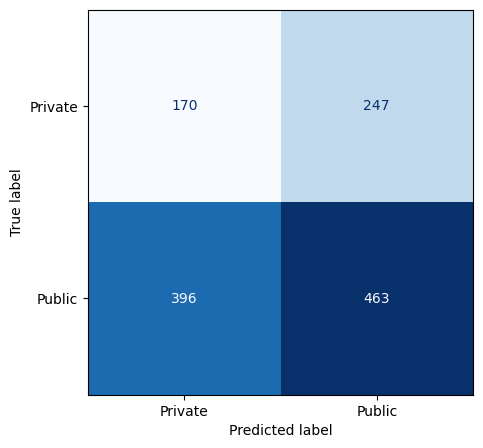

In [9]:
# Print accuracy score and report
print(f"Accuracy: {acc_lr:.4f}\n")
print("Classification Report:")
print(report_lr)

# Create confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
        y_test_class, 
        y_pred_lr, 
        ax=ax, 
        cmap='Blues',
        colorbar=False
    )

**The** accuracy score comes out to $0.4961$. The logistic model didn't find any correlation between exam score and school type. Let's see if the random forest classifier does any better: Below is the same metrics for evaluation on the random forest classifier as the ones used for logistic regression.

Accuracy: 0.4875

Classification Report:
              precision    recall  f1-score   support

     Private       0.31      0.46      0.37       417
      Public       0.66      0.50      0.57       859

    accuracy                           0.49      1276
   macro avg       0.48      0.48      0.47      1276
weighted avg       0.54      0.49      0.50      1276



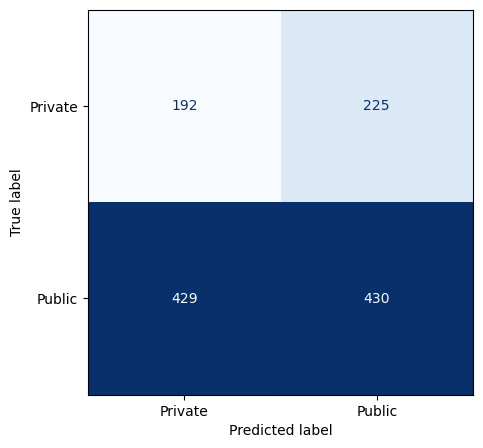

In [10]:
# Print accuracy score and report
print(f"Accuracy: {acc_rfc:.4f}\n")
print("Classification Report:")
print(report_rfc)

# Create confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
        y_test_class, 
        y_pred_rfc, 
        ax=ax, 
        cmap='Blues',
        colorbar=False
    )

**The** accuracy score for the random forest classifier is even worse, with a score of $0.4875$. This model substaintiates the claim that exam scores and school types are uncorrelated.

Now, the regression models. First, the forward feature selection linear regression model will be evaluated.


Forward Selection
Optimal Number of Features: 24 (Out of 27)
Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Family_Income_Low', 'Peer_Influence_Positive', 'Parental_Education_Level_High School', 'Motivation_Level_Low', 'Distance_from_Home_Near', 'Extracurricular_Activities_Yes', 'Learning_Disabilities_Yes', 'Internet_Access_Yes', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Family_Income_Medium', 'Physical_Activity', 'Motivation_Level_Medium', 'Parental_Education_Level_Postgraduate', 'Peer_Influence_Neutral', 'Distance_from_Home_Moderate']
Out-of-Sample (Test) R-squared: 0.742
Out-of-Sample (Test) RMSE: 1.972
Top 3 Most Impactful Features (by absolute coefficient): ['Access_to_Resources_Low', 'Parental_Involvement_Low', 'Family_Income_Low']


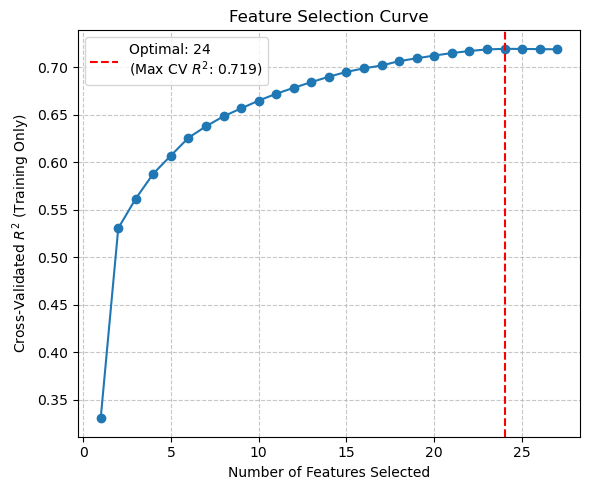

In [11]:
# Execute the forward feature selection linear regression model
plot_and_evaluate_forward_selection(X_train, X_test, y_train, y_test)

**The** forward feature selection used 24 out of the 27 features, with `Access_to_Resources_Low`, `Parental_Involvement_Low`, and `Family_Income_Low` being the three most impactful features in terms of model performance. Next, the backward feature selection linear regression model was evaluated.


Backward Selection
Optimal Number of Features: 24 (Out of 27)
Selected Features: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']
Out-of-Sample (Test) R-squared: 0.742
Out-of-Sample (Test) RMSE: 1.972
Top 3 Most Impactful Features (by absolute coefficient): ['Access_to_Resources_Low', 'Parental_Involvement_Low', 'Family_Income_Low']


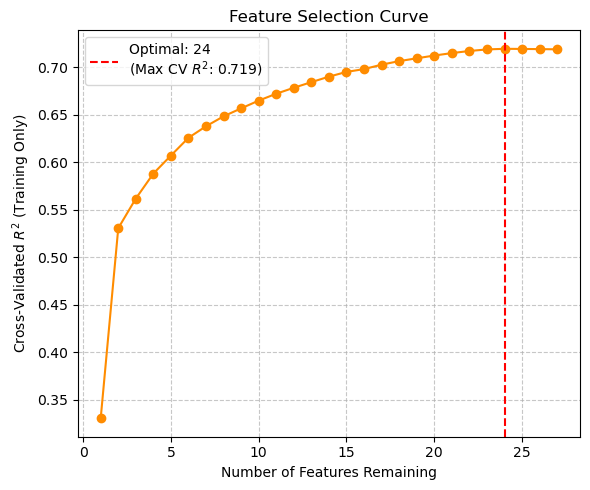

In [12]:
# Execute the backward feature selection linear regression model
plot_and_evaluate_backward_selection(X_train, X_test, y_train, y_test)

**The** results for the backward feature selection linear regression model were the exact same as that of forward feature selection linear regression. This isn't usually the case, as both algorithms are greedy and don't evaluate all of the features each loop, but due to the small size of the dataset used and the large impact of the top features, backward selection returned the same subset of features as forward selection. School type is again not included in the subset. Next, the pruned random forest was evaluated.

In [13]:
# Execute the post-train pruned random forest regression model
evaluate_pruned_random_forest(X_train, X_test, y_train, y_test)


Random Forest Pruning
Running Grid Search...
Best ccp_alpha: 0.0000
Test Set R-squared: 0.622
Test Set RMSE: 2.386
Top 3 Most Impactful Features (by RF Importance): ['Attendance', 'Hours_Studied', 'Previous_Scores']


**It** turns out that the most optimal random forest is one in which no nodes are pruned, as the grid search cross-validation gave $0$ as the optimal `ccp_alpha` value. This time, the three most impactful features were `Attendance`, `Hours_Studied`, and `Previous_Scores`. School type is, yet again, nowhere to be found. Lastly, the unpruned tree with 5-fold cross validation was evaluated.

In [14]:
# Execute the unpruned random forest regression model with 5-fold CV
evaluate_unpruned_random_forest(X_encoded, y)


Unpruned Random Forest 5-Fold CV
Individual R-squared scores: [0.528 0.603 0.587 0.621 0.7  ]
Average R-squared: 0.608 (Standard Deviation: +/- 0.056)
Individual RMSE scores: [2.749 2.482 2.498 2.403 2.098]
Average RMSE: 2.446 (Standard Deviation: +/- 0.209)
Top 3 Most Impactful Features (by RF Importance): ['Attendance', 'Hours_Studied', 'Previous_Scores']


**The** top three most impactful features for the unpruned random forest regressor were the same as for the pruned tree, with school type not playing a major role in predicting exam score.

---

## Discussion and Conclusion

The results indicate that the type of school a student goes to has zero correlation to the exam score they achieve, which implies that paying extra for private school will not determine what exam score they get. We can see this in the accuracy scores for the classification models we trained. For logistic regression, the accuracy score was $0.4961$, which indicates that the model is performing even worse than if you were to pick a school type randomly per test observation. The random forest classifier was even worse, with a score of $0.4875$. This already displays the lack of correlation between exam score and school type, and the regression models only back up this claim. For the linear regression models using forward feature selection and backward feature selection, the top three features were `Access_to_Resources_Low`, `Parental_Involvement_Low`, and `Family_Income_Low`. Intriguingly, there were three features that _weren't_ selected by the forward selection and backward selection algorithm, and `School_Type` was one of them. For the pruned random forest regressor and the unpruned random forest regressor using 5-fold cross validation, the top three features were `Attendance`, `Hours_Studied`, and `Previous_Scores`. School type was never chosen as an impactful feature for any of the regression models. Because of this, it's safe to say that paying extra for private school doesn't change what exam score a student will get, and is therefore not worth the cost in that regard.

One obstacle we ran into when creating our models was the size of the dataset. Relatively speaking, it doesn't contain very many observations, and is therefore bound to train weaker models because of it. If there were more observations, it would provide a bigger picture to regression and classification models, allowing for them to fit patterns in the data that may not be as obvious in a smaller dataset. Another obstacle was a lack of substantial features pertaining to school type. Private schools offer professional connections, tutors, and other advantages that public schools might not have. These advantages could justify the substantial cost for tuition, and could therefore lead us to come to an alternate conclusion. Exam score is a simple metric to use as a gauge for academic performance of a student coming out of a certain school type, which is both a pro and a con. It's a pro, as it's easy to analyze, but a con in that it lacks nuance.

For future testing, we'd train our models on a larger dataset. This would allow for more patterns in the data to be detected, potentially improving model accuracy. We'd also like to explore different metrics of academic performance. More academic performance metrics, like college admission rate, homework grades, or standardized test scores (i.e. SAT scores, ACT scores) could contain a correlation with school type and potentially justify the cost of private school. Finally, we would also use more computational techniques to select features and subsidize data for the models in order to improve our chances of finding the optimal model with the highest accuracy/test score that could more definitively tell us how significant school type is as a feature.

---

## Author contribution

**Jack's Contributions**: Random Forest Regressors, Data, Methodology, Discussion & Conclusion, Video Editing

**Kathryn's Contributions**: Linear Regression Models, Background & Motivation, Slides, Video Recording

**Feedback for Jack**: He tried to implement an imputer for the data, but it was incorrectly implemented, which caused test data to leak into the training data, plus it didn't make sense to do this given the scope of the project.

**Feedback for Kathryn**: She copied and pasted similar code blocks for the linear regression models when it could've been made into a function, which would've made debugging easier.

---

## References

[1]    J. Smith, “See what Michigan private high schools are the most expensive to attend,” mlive, Nov. 22, 2024. https://www.mlive.com/news/ann-arbor/2024/11/see-what-michigan-private-high-schools-are-the-most-expensive-to-attend.html 
‌

[2]    “Post pruning decision trees with cost complexity pruning,” scikit-learn. https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
‌

---